In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton

%config InlineBackend.figure_formats = ['svg']

# Rate Periodicity Conversion
def equivRate(rate, from_freq=1, to_freq=1):
    return to_freq * ((1 + rate/from_freq)**(from_freq/to_freq) - 1)

# Present Value Function
def pv(r, n, pmt, fv=0, beg=False):
    c = np.full(n, pmt)
    t = np.arange(1, n+1)
    d = (1. / np.power((1 + r), t))
    B = np.sum(d * c)
    tv = fv / (1 + r)**n

    return np.where(beg, (B + tv) * (1 + r), B + tv)

# Amortizing Loan Principal Outstanding Balance
def principal_out(P, r, N, n):
    d1 = (1 + r)**N - (1 + r)**(n-1)
    d2 = (1 + r)**N - 1
    return P * d1/d2

fx_rate = 1/3.67
currency = "AED"

In [2]:
start_date = pd.to_datetime("2020-01-01")
end_date = pd.DateOffset(months=12*12) + start_date
eval_end_date = pd.to_datetime('2025-06-01')

# Real Estate Investment
property_val = 510_000
down_payment = property_val * 0.2
loan_amount = property_val - down_payment
closing_costs = 28_000
emi = 3_500
n_period = 12 * 12

interest_rate = newton(
	lambda r: pv(r=r, n=n_period, pmt=emi, beg=False) - loan_amount,
	x0=0
)

annual_rent = 36_000
annual_rent_gwth = 0.05
service_fee = 15 * 484
annual_appreciation = 0.05
monthly_appreciation = equivRate(annual_appreciation, 1, 12)/12

# Equity Market Investment
snp500 = yf.Ticker("VOO") # Vanguard S&P 500 ETF (VOO)
snp500_hist = snp500.history(start=start_date, end=end_date)
snp500_hist.reset_index(inplace=True)
snp500_hist[['Open', 'High', 'Low', 'Close', 'Dividends']] *= fx_rate

### Real Estate Investment

In [4]:
months = np.arange(n_period+1)
dates = pd.date_range(start=start_date, end=end_date, freq="MS")
emi_cf = np.insert(np.full(n_period, emi), 0, 0)
principal_bal = principal_out(loan_amount, interest_rate, n_period, months+1)
interest_portion = np.roll(principal_bal, 1) * interest_rate
principal_portion = emi_cf - interest_portion
prop_value = property_val * (1 + monthly_appreciation)**months
rental_income = np.zeros(months.shape)
rental_income[12::12] = annual_rent * (1 + annual_rent_gwth)**(months[12::12] / 12) - service_fee

home_investment_schedule = pd.DataFrame({
    'Date': dates,
	'Month': months,
	'Principal Balance': principal_bal,
	'Interest Portion': interest_portion,
	'Principal Portion': principal_portion,
	'EMI': emi_cf,
	'Property Value': prop_value,
	'Equity': prop_value - principal_bal,
	'Net Rental Income': rental_income
})

home_investment_schedule

,Date,Month,Principal Balance,Interest Portion,Principal Portion,EMI,Property Value,Equity,Net Rental Income
0,2020-01-01,0,408000.000000,0.000000,0.000000,0,510000.000000,102000.000000,0.000000
1,2020-02-01,1,405735.398958,1235.398958,2264.601042,3500,512077.803130,106342.404171,0.000000
2,2020-03-01,2,403463.940843,1228.541885,2271.458115,3500,514164.071486,110700.130643,0.000000
3,2020-04-01,3,401185.604893,1221.664049,2278.335951,3500,516258.839559,115073.234666,0.000000
4,2020-05-01,4,398900.370281,1214.765388,2285.234612,3500,518362.141976,119461.771695,0.000000
...,...,...,...,...,...,...,...,...,...
140,2031-09-01,140,13894.660553,52.510965,3447.489035,3500,901111.776061,887217.115508,0.000000
141,2031-10-01,141,10436.732732,42.072179,3457.927821,3500,904783.016980,894346.284248,0.000000
142,2031-11-01,142,6968.334518,31.601786,3468.398214,3500,908469.214988,901500.880470,0.000000
143,2031-12-01,143,3489.434207,21.099689,3478.900311,3500,912170.431024,908680.996816,0.000000


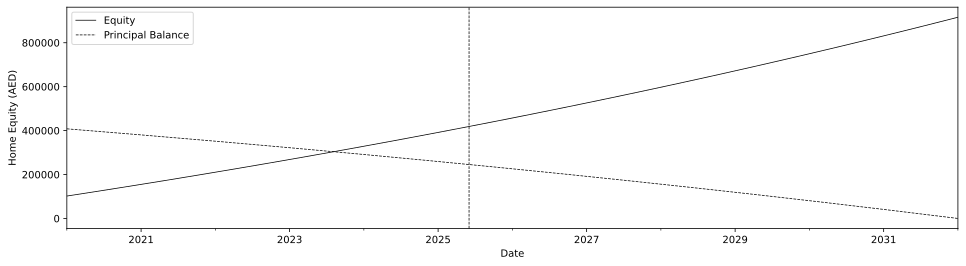

In [5]:
fig, ax = plt.subplots(figsize=(16,4))
home_investment_schedule.plot(x = 'Date', y = 'Equity', color='k', linewidth=0.75, ax=ax)
home_investment_schedule.plot(x = 'Date', y = 'Principal Balance', color='k', linestyle='--', linewidth=0.75,ax=ax)
ax.axvline(eval_end_date, color='k', linewidth=0.75, linestyle='--')
ax.set(xlabel='Date', ylabel=f"Home Equity ({currency})")
plt.legend();

In [6]:
i = np.searchsorted(dates, eval_end_date)
t = (eval_end_date - start_date).total_seconds() / (60**2 * 24 * 365)
print(f"Home Value - Start ({currency}) = {property_val:,.2f}")
print(f"Home Value - Mid 2025 ({currency}) = {prop_value[i]:,.2f}")
print(f"% Increase in Home Value = {prop_value[i] / property_val - 1:.2%}")
print(f"Property Value Appreciation (CAGR) = {(prop_value[i] / property_val)**(1/t) - 1:,.2%}")
print()

total_investment = principal_portion[:i+1].sum() + down_payment
current_home_equity = prop_value[i] - principal_bal[i]
print(f"Total Investment ({currency}) = {total_investment:,.2f}")
print(f"Home Equity Value ({currency}) = {current_home_equity:,.2f}")
print(f"Total Rental Income ({currency}) = {rental_income[:i+1].sum():,.2f}")

hpr = (current_home_equity - total_investment + rental_income[:i+1].sum() - interest_portion[:i+1].sum() - closing_costs) / total_investment
print(f"Holding Period Return = {hpr:,.2%}")

Home Value - Start (AED) = 510,000.00
Home Value - Mid 2025 (AED) = 664,271.39
% Increase in Home Value = 30.25%
Property Value Appreciation (CAGR) = 5.00%

Total Investment (AED) = 264,412.88
Home Equity Value (AED) = 418,684.27
Total Rental Income (AED) = 172,568.86
Holding Period Return = 88.40%


### S&P 500 Investment

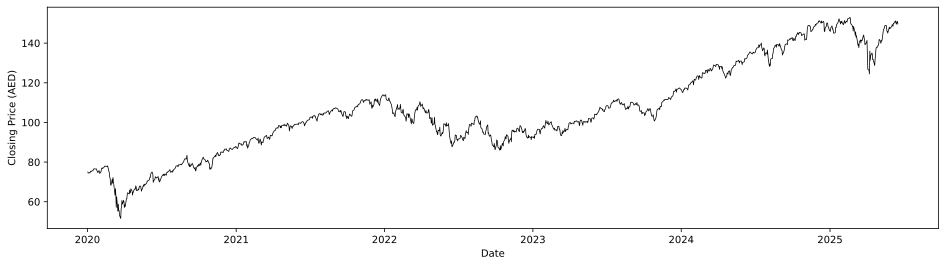

In [7]:
plt.figure(figsize=(16, 4))
plt.plot(snp500_hist['Date'], snp500_hist['Close'], color='k', linewidth=0.75)
plt.xlabel('Date')
plt.ylabel(f'Closing Price ({currency})');

In [20]:
# S&P 500 Value CAGR
t = (snp500_hist['Date'].iloc[-1] - snp500_hist['Date'].iloc[0]).total_seconds() / (60**2 * 24 * 365)
cagr = (snp500_hist['Close'].iloc[-1] / snp500_hist['Close'].iloc[0])**(1/t) - 1
print(f"S&P 500 CAGR = {cagr:.2%}")

S&P 500 CAGR = 13.50%


In [9]:
investment_dates = np.flatnonzero(np.diff(snp500_hist['Date'].dt.month, prepend=start_date.month))
monthly_investment = np.zeros(snp500_hist.shape[0])
monthly_investment[investment_dates] = principal_portion[1:i+1]
monthly_investment[0] = down_payment + closing_costs

trading_fees = monthly_investment * 0.0025
trading_fees = np.where(trading_fees < 1, np.where(trading_fees < 0, 0, 1), trading_fees)

investment_df = pd.DataFrame()
investment_df['Date'] = snp500_hist['Date']
investment_df['Investments'] = monthly_investment
investment_df['Delta Shares'] = investment_df['Investments'] / snp500_hist['Open']
investment_df['Total Shares'] = investment_df['Delta Shares'].cumsum()
investment_df['Portfolio Value'] = investment_df['Total Shares'] * snp500_hist['Close']
investment_df['Avg Price'] = investment_df['Investments'].cumsum() / investment_df['Total Shares']
investment_df['Dividend Income'] = (investment_df['Total Shares'] * snp500_hist['Dividends']) * (1 - 0.3) # Withholding Tax 30%

investment_df

,Date,Investments,Delta Shares,Total Shares,Portfolio Value,Avg Price,Dividend Income
0,2020-01-02 00:00:00-05:00,130000.0,1740.481189,1740.481189,130494.132431,74.691988,0.0
1,2020-01-03 00:00:00-05:00,0.0,0.000000,1740.481189,129540.807397,74.691988,0.0
2,2020-01-06 00:00:00-05:00,0.0,0.000000,1740.481189,130026.197028,74.691988,0.0
3,2020-01-07 00:00:00-05:00,0.0,0.000000,1740.481189,129667.647242,74.691988,0.0
4,2020-01-08 00:00:00-05:00,0.0,0.000000,1740.481189,130336.697032,74.691988,0.0
...,...,...,...,...,...,...,...
1367,2025-06-11 00:00:00-04:00,0.0,0.000000,3327.868090,501320.191706,87.867931,0.0
1368,2025-06-12 00:00:00-04:00,0.0,0.000000,3327.868090,503215.377995,87.867931,0.0
1369,2025-06-13 00:00:00-04:00,0.0,0.000000,3327.868090,497611.508670,87.867931,0.0
1370,2025-06-16 00:00:00-04:00,0.0,0.000000,3327.868090,502417.410647,87.867931,0.0


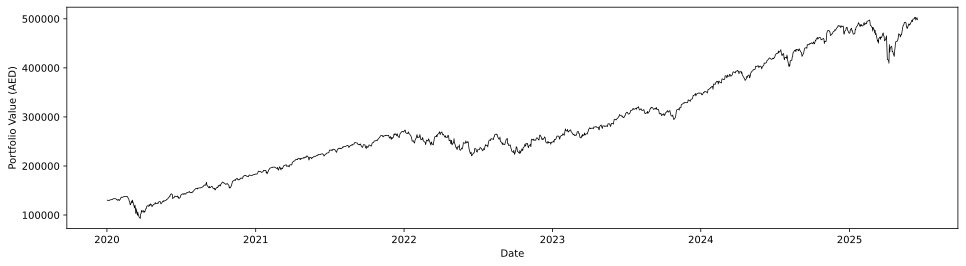

In [10]:
plt.figure(figsize=(16, 4))
plt.plot(investment_df['Date'], investment_df['Portfolio Value'], color='k', linewidth=0.75)
plt.xlabel('Date')
plt.ylabel(f'Portfolio Value ({currency})');

In [11]:
portfolio_value_end = investment_df['Portfolio Value'].to_numpy()[-1]
total_invested = investment_df['Investments'].sum()
total_dividends = investment_df['Dividend Income'].sum()
snp500_return = (portfolio_value_end + total_dividends - total_invested) / total_invested

print(f"Total Investment ({currency}) = {total_invested:,.2f}")
print(f"Portfolio Value ({currency}) = {portfolio_value_end:,.2f}")
print(f"Dividend Income After Tax ({currency}) = {total_dividends:,.2f}")

print(f"Holding Period Return = {snp500_return:.2%}")

Total Investment (AED) = 292,412.88
Portfolio Value (AED) = 498,137.40
Dividend Income After Tax (AED) = 15,861.03
Holding Period Return = 75.78%
